В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [151]:
cars_df = pd.read_csv('../../Sample Data/cars.csv')

display(cars_df.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [152]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [153]:
cols = cars_df.select_dtypes(object).columns

for col in cols:
    print(f'{col}:{cars_df[col].unique()}')

Brand:['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
Model:['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
Fuel_Type:['Petrol' 'Diesel']
Transmission:['Manual' 'Automatic']
Owner_Type:['First' 'Second' 'Third']


В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні: `Fuel_Type`,`Transmission`
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку: `Brand`, `Model` 
- 1 категоріальна з порядком: `Owner_Type`

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [154]:
inputs = cars_df.drop(columns=['Price'])
targets = cars_df['Price']

In [155]:
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.1, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [156]:
fuel_major = X_train['Fuel_Type'].value_counts().idxmax()
trans_major = X_train['Transmission'].value_counts().idxmax()

X_train['Fuel_Type_Code'] = (X_train['Fuel_Type'] == fuel_major).astype(int)
X_test['Fuel_Type_Code'] = (X_test['Fuel_Type'] == fuel_major).astype(int)

X_train['Transmission_Code'] = (X_train['Transmission'] == trans_major).astype(int)
X_test['Transmission_Code'] = (X_test['Transmission'] == trans_major).astype(int)

print(f"Fuel_Type: 1 -> {fuel_major}")
print(f"Transmission: 1 -> {trans_major}")
print(X_train.head())

Fuel_Type: 1 -> Diesel
Transmission: 1 -> Automatic
    Car_ID       Brand  Model  Year  Kilometers_Driven Fuel_Type Transmission  \
12      13     Hyundai  Creta  2019              22000    Petrol       Manual   
8        9        Audi     A4  2017              30000    Diesel    Automatic   
39      40      Toyota  Yaris  2020              18000    Petrol       Manual   
9       10         BMW     X1  2019              20000    Diesel    Automatic   
7        8  Volkswagen   Polo  2020              25000    Petrol    Automatic   

   Owner_Type  Mileage  Engine  Power  Seats  Fuel_Type_Code  \
12      Third       16    1497    113      5               0   
8       First       18    1968    187      5               1   
39      First       17    1496    106      5               0   
9      Second       20    1995    190      5               1   
7       First       18     999     76      5               0   

    Transmission_Code  
12                  0  
8                   1  
39  

In [178]:
brand_train_raw = cars_df.loc[X_train.index, 'Brand']
brand_test_raw = cars_df.loc[X_test.index, 'Brand']

X_train['Brand'] = brand_train_raw
X_test['Brand'] = brand_test_raw

enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])

OneHotEncoder()

In [179]:
brand_cols = enc.get_feature_names_out(['Brand'])

train_one_hot = pd.DataFrame(
    enc.transform(X_train[['Brand']]).toarray(),
    columns=brand_cols,
    index=X_train.index,
)
test_one_hot = pd.DataFrame(
    enc.transform(X_test[['Brand']]).toarray(),
    columns=brand_cols,
    index=X_test.index,
)

X_train = pd.concat([X_train, train_one_hot], axis=1)
X_test = pd.concat([X_test, test_one_hot], axis=1)

display(X_train.head())
display(X_test.head())

,Car_ID,Brand,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen
12,13,Hyundai,2019,22000,16,1497,113,5,0,0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,Audi,2017,30000,18,1968,187,5,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39,40,Toyota,2020,18000,17,1496,106,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,10,BMW,2019,20000,20,1995,190,5,1,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,Volkswagen,2020,25000,18,999,76,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen
17,18,Audi,2016,38000,15,1395,148,5,0,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41,42,Hyundai,2019,26000,20,1086,68,5,0,0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
92,93,Volkswagen,2017,32000,18,1598,103,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,15,Maruti,2020,18000,19,1462,103,7,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
68,69,Ford,2019,26000,20,1194,94,5,0,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [159]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [160]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes
12,13,0.0,Creta,2019,22000,Petrol,Manual,Third,16,1497,113,5,0,0,2.0
8,9,1.0,A4,2017,30000,Diesel,Automatic,First,18,1968,187,5,1,1,0.0
39,40,0.0,Yaris,2020,18000,Petrol,Manual,First,17,1496,106,5,0,0,0.0
9,10,0.0,X1,2019,20000,Diesel,Automatic,Second,20,1995,190,5,1,1,1.0
7,8,0.0,Polo,2020,25000,Petrol,Automatic,First,18,999,76,5,0,1,0.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes
17,18,1.0,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,0,1,1.0
41,42,0.0,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0,0,2.0
92,93,0.0,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,0,1.0
14,15,0.0,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0,0,0.0
68,69,0.0,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0,0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [161]:
X_train = X_train.select_dtypes(include='number')

X_train_num = pd.concat([X_train, y_train], axis=1)
display(X_train_num)

,Car_ID,Brand,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Price
12,13,0.0,2019,22000,16,1497,113,5,0,0,2.0,850000
8,9,1.0,2017,30000,18,1968,187,5,1,1,0.0,2200000
39,40,0.0,2020,18000,17,1496,106,5,0,0,0.0,650000
9,10,0.0,2019,20000,20,1995,190,5,1,1,1.0,2700000
7,8,0.0,2020,25000,18,999,76,5,0,1,0.0,650000
...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,0.0,2020,30000,23,1248,74,5,1,0,2.0,600000
2,3,0.0,2017,20000,10,4951,395,4,0,1,0.0,2500000
6,7,0.0,2018,45000,15,2179,140,7,1,1,1.0,900000
27,28,0.0,2019,22000,18,1995,187,5,1,1,1.0,2800000


,Car_ID,Brand,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes,Price
Car_ID,1.000000,0.046009,0.072181,-0.254793,0.067928,-0.043566,0.026295,0.006858,-0.075603,-0.088301,0.034929,0.041418
Brand,0.046009,1.000000,-0.281660,0.100755,-0.123970,0.082199,0.166375,0.092489,0.029637,0.272166,-0.202145,0.326524
Year,0.072181,-0.281660,1.000000,-0.725120,0.260074,-0.394797,-0.271768,-0.327216,-0.250858,-0.202219,-0.044502,-0.250553
Kilometers_Driven,-0.254793,0.100755,-0.725120,1.000000,-0.139804,0.115837,-0.033978,0.460307,0.316582,-0.051827,0.003259,-0.065217
Mileage,0.067928,-0.123970,0.260074,-0.139804,1.000000,-0.698187,-0.652233,-0.208855,0.047346,-0.310565,0.025630,-0.584690
Engine,-0.043566,0.082199,-0.394797,0.115837,-0.698187,1.000000,0.794401,0.184646,0.218045,0.401764,-0.173029,0.698916
Power,0.026295,0.166375,-0.271768,-0.033978,-0.652233,0.794401,1.000000,-0.113577,-0.044947,0.561884,-0.173700,0.847581
Seats,0.006858,0.092489,-0.327216,0.460307,-0.208855,0.184646,-0.113577,1.000000,0.387578,-0.107314,-0.023616,-0.005750
Fuel_Type_Code,-0.075603,0.029637,-0.250858,0.316582,0.047346,0.218045,-0.044947,0.387578,1.000000,0.018149,-0.290562,0.147627
Transmission_Code,-0.088301,0.272166,-0.202219,-0.051827,-0.310565,0.401764,0.561884,-0.107314,0.018149,1.000000,-0.020631,0.672994


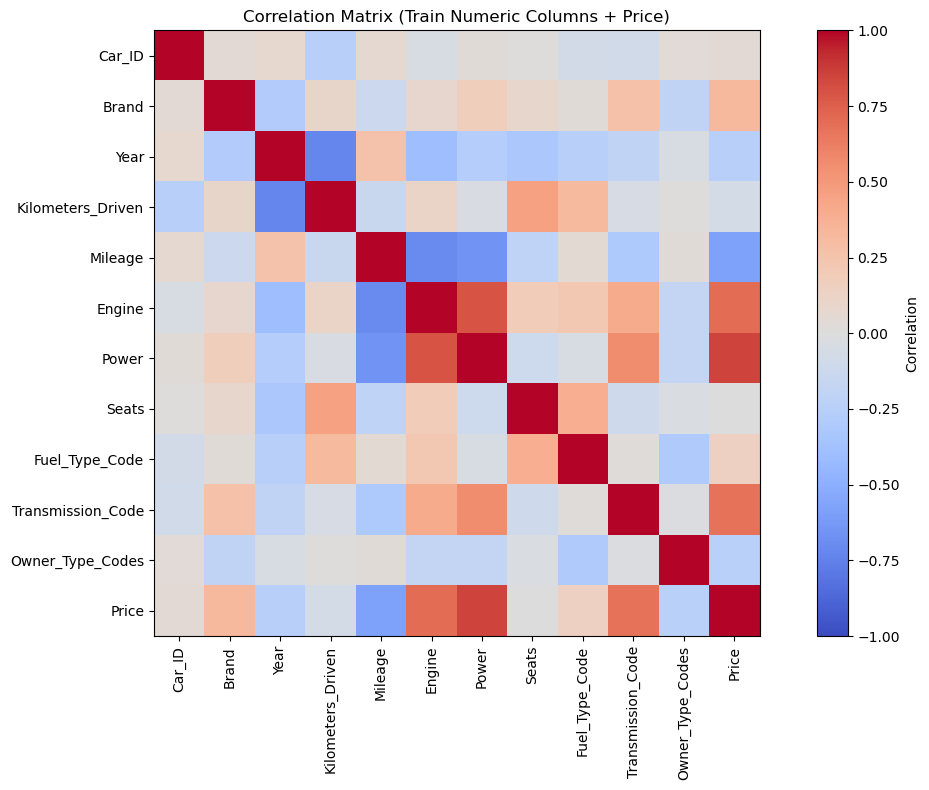

In [162]:
corr_matrix = X_train_num.corr()

display(corr_matrix)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix (Train Numeric Columns + Price)')
plt.tight_layout()
plt.show()

In [163]:
target_corr = corr_matrix['Price'].drop('Price')
strong_corr = target_corr[target_corr.abs() > 0.5]
print("Колонки, які найбільше корелюють з Price:")
for feature, corr_val in strong_corr.items():
    print(f'{feature}: {corr_val:.3f}')

Колонки, які найбільше корелюють з Price:
Mileage: -0.585
Engine: 0.699
Power: 0.848
Transmission_Code: 0.673


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [164]:
X_test = X_test.select_dtypes(include='number')

In [165]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

predictions_x_train_sklearn = lin_reg.predict(X_train)
predictions_x_test_sklearn = lin_reg.predict(X_test[X_train.columns])

mse_train = mean_squared_error(y_train, predictions_x_train_sklearn)
rmse_train = np.sqrt(mse_train)
mse_test = mean_squared_error(y_test, predictions_x_test_sklearn)
rmse_test = np.sqrt(mse_test)

rmse_test, rmse_train 

(286776.8122228467, 393040.21676473704)

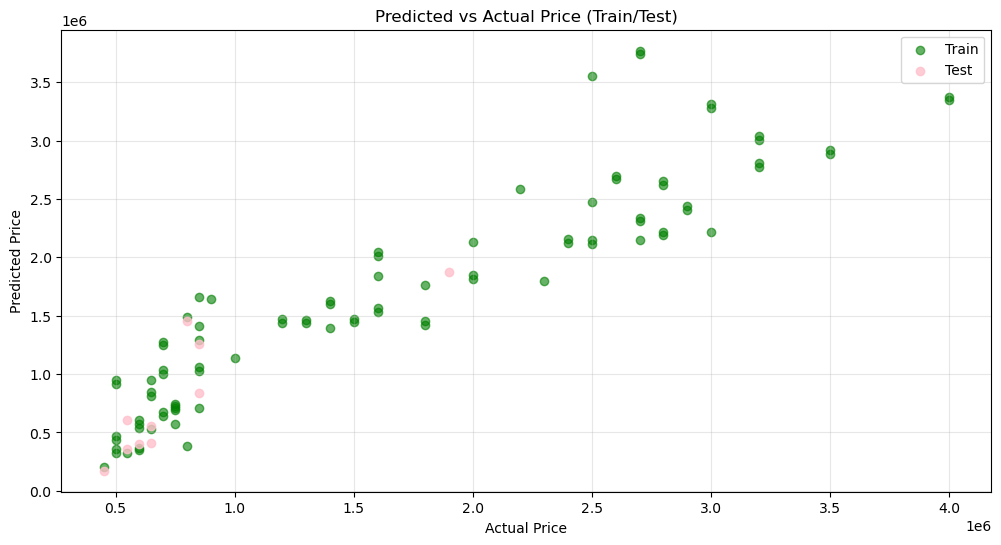

In [166]:
plt.figure(figsize=(12, 6))

plt.scatter(y_train, predictions_x_train_sklearn, color='green', alpha=0.6, label='Train')
plt.scatter(y_test, predictions_x_test_sklearn, color='pink', alpha=0.8, label='Test')

plt.title('Predicted vs Actual Price (Train/Test)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Модель лінійної регресії показує посередню якість і не є достатньо точною для надійного практичного використання. На графіку видно помітні відхилення передбачень від реальних значень, особливо для частини об’єктів із вищою ціною, а значення RMSE залишаються досить великими. Отже, модель вловлює загальну тенденцію, але прогнозує неточно, тому її варто покращувати.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [167]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test[X_train.columns])

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns, index=X_test.index)

In [168]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled_df, y_train)

predictions_x_train_sklearn = lin_reg.predict(X_train_scaled_df)
predictions_x_test_sklearn = lin_reg.predict(X_test_scaled_df[X_train_scaled_df.columns])

mse_train = mean_squared_error(y_train, predictions_x_train_sklearn)
rmse_train = np.sqrt(mse_train)
mse_test = mean_squared_error(y_test, predictions_x_test_sklearn)
rmse_test = np.sqrt(mse_test)

coef_scaled = pd.Series(lin_reg.coef_, index=X_train_scaled_df.columns)
print('Top 5 coefficients by absolute value (scaled features):')
display(coef_scaled.abs().sort_values(ascending=False).head(5))

print(f'RMSE train: {rmse_train:.2f}')
print(f'RMSE test: {rmse_test:.2f}')

Top 5 coefficients by absolute value (scaled features):


Power                659301.383099
Transmission_Code    250835.211772
Fuel_Type_Code       202715.630504
Kilometers_Driven    161631.461136
Mileage              133943.725476
dtype: float64

RMSE train: 393040.22
RMSE test: 286776.81


**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [169]:
X_train_scaled_sm = sm.add_constant(X_train_scaled_df)
model_8 = sm.OLS(y_train, X_train_scaled_sm)
results_8 = model_8.fit()
results_8.params

const                1.661667e+06
Car_ID               2.426304e+04
Brand                1.237109e+05
Year                -3.768919e+04
Kilometers_Driven   -1.616315e+05
Mileage             -1.339437e+05
Engine              -8.474537e+04
Power                6.593014e+05
Seats                5.445165e+04
Fuel_Type_Code       2.027156e+05
Transmission_Code    2.508352e+05
Owner_Type_Codes    -4.844110e+04
dtype: float64

In [170]:
print(results_8.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     39.11
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           3.25e-27
Time:                        22:39:20   Log-Likelihood:                -1287.1
No. Observations:                  90   AIC:                             2598.
Df Residuals:                      78   BIC:                             2628.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.662e+06   4.45e+0

In [171]:
significant = [col for col, pval in results_8.pvalues.items() if pval < 0.05 and col != 'const']
print('Статистично значущі ознаки (p < 0.05):', significant)

Статистично значущі ознаки (p < 0.05): ['Brand', 'Power', 'Fuel_Type_Code', 'Transmission_Code']


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [172]:
X_train_scaled_selected_df = X_train_scaled_df[significant]
X_test_scaled_selected_df = X_test_scaled_df[significant]

X_train_scaled_sm_9 = sm.add_constant(X_train_scaled_selected_df)
model_9 = sm.OLS(y_train, X_train_scaled_sm_9)
results_9 = model_9.fit()
results_9.params

const                1.661667e+06
Brand                1.406149e+05
Power                6.992857e+05
Fuel_Type_Code       1.710021e+05
Transmission_Code    2.409061e+05
dtype: float64

In [173]:
print(results_9.summary())
print('\nПорівняння Task 8 vs Task 9:')
print(f"R2: {results_8.rsquared:.4f} -> {results_9.rsquared:.4f}")
print(f"Adj. R2: {results_8.rsquared_adj:.4f} -> {results_9.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     99.01
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           3.67e-31
Time:                        22:39:20   Log-Likelihood:                -1293.4
No. Observations:                  90   AIC:                             2597.
Df Residuals:                      85   BIC:                             2609.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.662e+06   4.57e+0

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [174]:
significant_p025 = [col for col, pval in results_8.pvalues.items() if pval < 0.25 and col != 'const']

X_train_scaled_selected_p025_df = X_train_scaled_df[significant_p025]
X_test_scaled_selected_p025_df = X_test_scaled_df[significant_p025]

X_train_scaled_sm_10 = sm.add_constant(X_train_scaled_selected_p025_df)
model_10 = sm.OLS(y_train, X_train_scaled_sm_10)
results_10 = model_10.fit()
results_10.params

const                1.661667e+06
Brand                1.519231e+05
Kilometers_Driven   -1.318248e+05
Mileage             -1.186654e+05
Power                6.187828e+05
Fuel_Type_Code       2.144423e+05
Transmission_Code    2.385878e+05
dtype: float64

In [175]:
print(results_10.summary())

print('\nПорівняння Task 8 vs Task 10:')
print(f"R2: {results_8.rsquared:.4f} -> {results_10.rsquared:.4f}")
print(f"Adj. R2: {results_8.rsquared_adj:.4f} -> {results_10.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     73.46
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           4.15e-31
Time:                        22:39:20   Log-Likelihood:                -1288.5
No. Observations:                  90   AIC:                             2591.
Df Residuals:                      83   BIC:                             2608.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.662e+06   4.38e+0

Найкраща модель остання, бо Adj R-squared = 0.811